In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [2]:
train_df = pd.read_csv("../data/processed/train_scaled.csv")
test_df = pd.read_csv("../data/processed/test_scaled.csv")

In [3]:
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [4]:
models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [5]:
results = []

In [6]:
for name, model in models.items():

    print("=" * 50)
    print(f"Training {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Prediction probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

Training Logistic Regression...
Accuracy : 0.8045
ROC-AUC  : 0.8361
Training Decision Tree...
Accuracy : 0.7164
ROC-AUC  : 0.6343
Training Random Forest...
Accuracy : 0.7882
ROC-AUC  : 0.8156
Training XGBoost...
Accuracy : 0.7711
ROC-AUC  : 0.8114


In [7]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.650456,0.572193,0.608819,0.836071
1,Decision Tree,0.716418,0.466125,0.459893,0.462988,0.634332
2,Random Forest,0.788202,0.623377,0.513369,0.563050,0.815628
3,XGBoost,0.771144,0.576023,0.526738,0.550279,0.811390


In [8]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.650456,0.572193,0.608819,0.836071
2,Random Forest,0.788202,0.623377,0.513369,0.563050,0.815628
3,XGBoost,0.771144,0.576023,0.526738,0.550279,0.811390
1,Decision Tree,0.716418,0.466125,0.459893,0.462988,0.634332


In [9]:
results_df.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


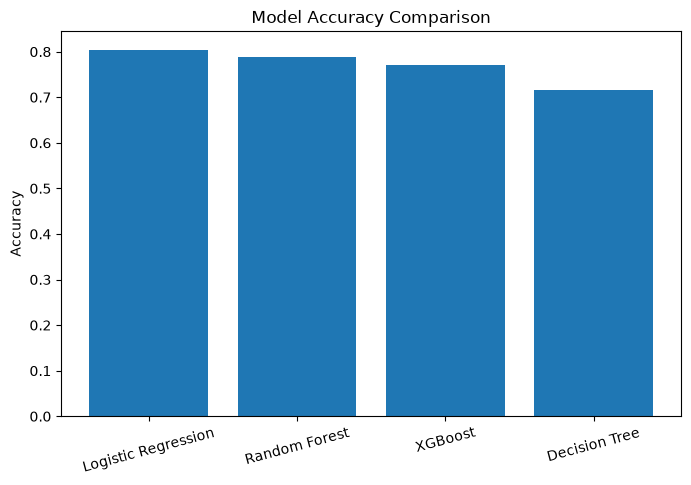

In [10]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

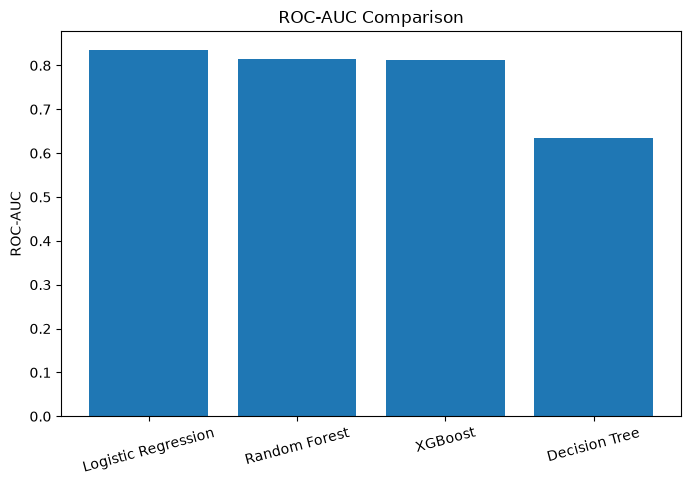

In [11]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["ROC-AUC"])

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=15)

plt.show()

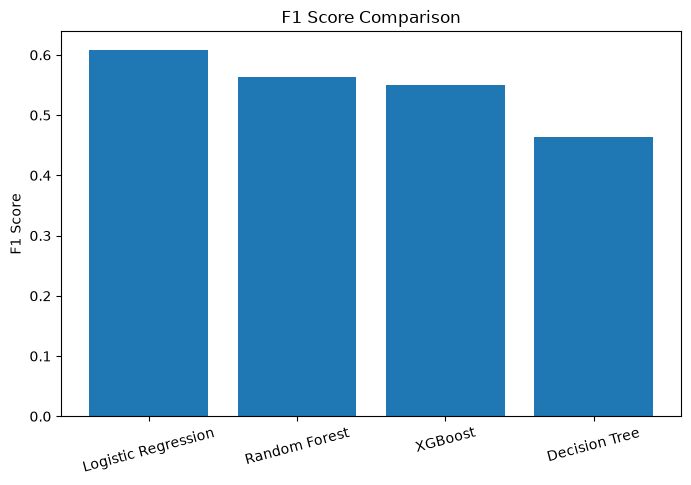

In [12]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["F1 Score"])

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.show()